In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Loading toy_user.csv...
Dataset shape: (1123284, 11)
Columns: ['user_id', 'user_url', 'last_online_date', 'num_watching', 'num_completed', 'num_on_hold', 'num_dropped', 'num_plan_to_watch', 'num_days', 'mean_score', 'clubs']

First few rows:
           user_id                                         user_url   
0         kir1yama         https://myanimelist.net/profile/Kir1yama  \
1         smatster         https://myanimelist.net/profile/smatster   
2        suzuhrevv        https://myanimelist.net/profile/SuzuhRevv   
3  pheseantnetsuke  https://myanimelist.net/profile/PheseantNetsuke   
4        skyuchiha        https://myanimelist.net/profile/SkyUchiha   

      last_online_date  num_watching  num_completed  num_on_hold  num_dropped   
0  2021-08-27 15:46:00            28            606           48           48  \
1  2022-02-25 11:13:03            46           1188          209           31   
2  2022-02-21 20:02:48            47            517          180           52   
3  2022

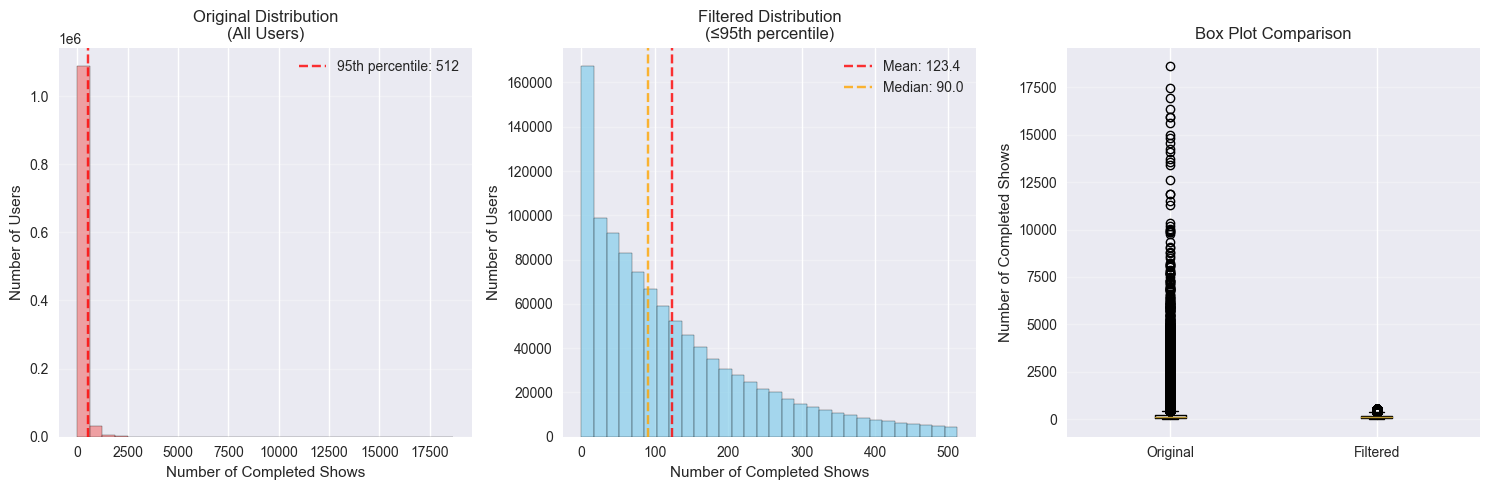

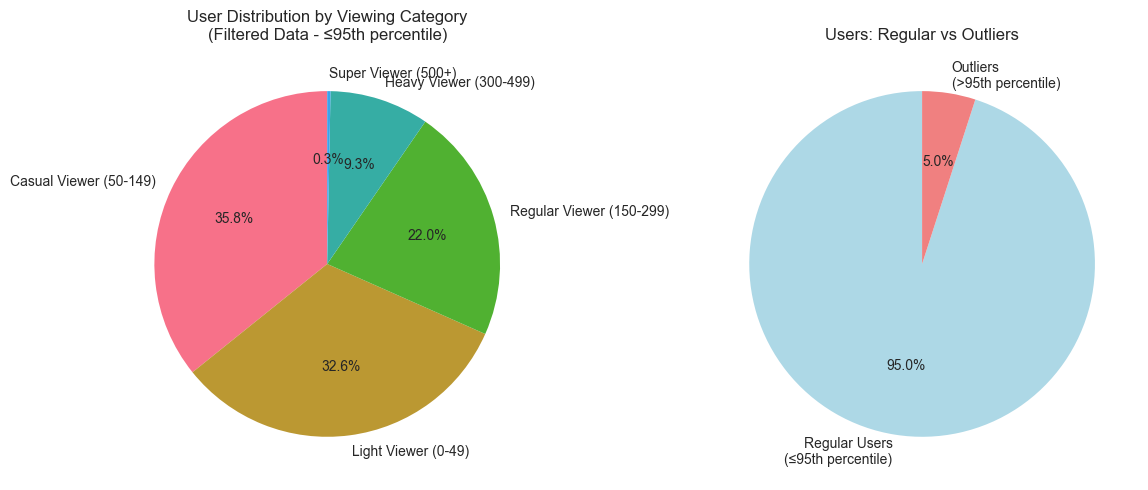


=== Viewer Category Breakdown (Filtered Data) ===
Casual Viewer (50-149): 381863 users (35.8%)
Light Viewer (0-49): 347735 users (32.6%)
Regular Viewer (150-299): 235203 users (22.0%)
Heavy Viewer (300-499): 99211 users (9.3%)
Super Viewer (500+): 3280 users (0.3%)

=== Outlier Analysis ===
Number of outliers (>95th percentile): 55992
Outlier completion range: 513 - 18659
Top 5 outliers:
  kim_kil_whan: 18659 completed shows
  hanaram: 17465 completed shows
  novio: 16954 completed shows
  houssamelouafi: 16358 completed shows
  greenlandball: 15921 completed shows

=== Correlations with Other Metrics (Filtered Data) ===
Correlation with num_completed (filtered data):
  num_days: 0.488
  num_plan_to_watch: 0.302
  num_on_hold: 0.249
  num_dropped: 0.244
  num_watching: 0.168
  mean_score: 0.064


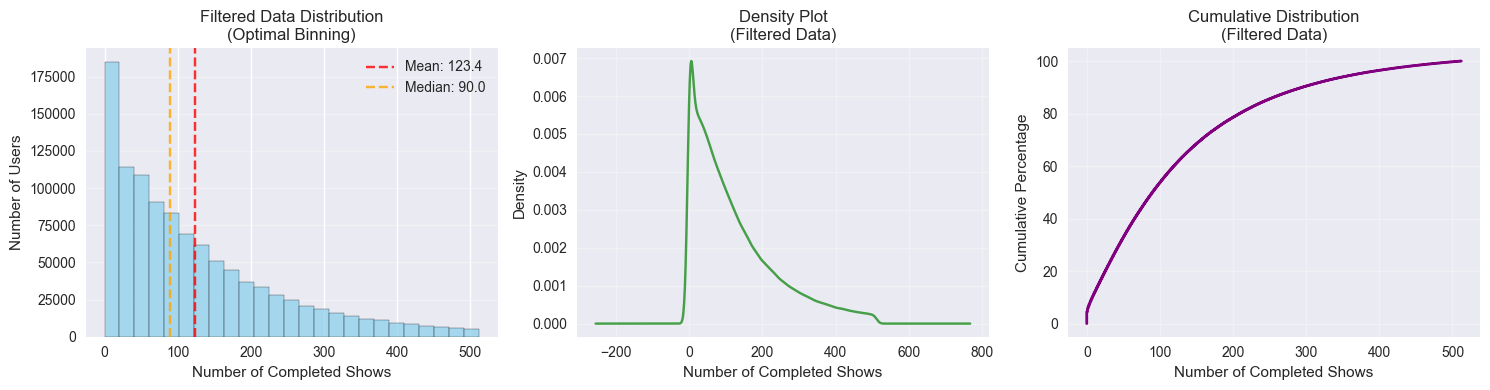


ANALYSIS SUMMARY
Original dataset: 1123284 users
Filtered dataset: 1067292 users (95.0%)
Outliers removed: 55992 users (5.0%)
95th percentile threshold: 512 completed shows
Filtered data mean: 123.4 completed shows
Filtered data median: 90.0 completed shows

Filtered data provides a cleaner view of typical user behavior!


In [3]:
# Load the data
print("Loading toy_user.csv...")
df = pd.read_csv('../data/user.csv')

# Basic data exploration
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())

# Focus on the num_completed column
completed_shows = df['num_completed']

# Calculate percentiles to identify outliers
percentile_95 = np.percentile(completed_shows, 95)
percentile_99 = np.percentile(completed_shows, 99)

# Basic statistics (original data)
print(f"\n=== Original Data Statistics ===")
print(f"Total users: {len(completed_shows)}")
print(f"Mean completed shows per user: {completed_shows.mean():.2f}")
print(f"Median completed shows per user: {completed_shows.median():.2f}")
print(f"Standard deviation: {completed_shows.std():.2f}")
print(f"Min completed shows: {completed_shows.min()}")
print(f"Max completed shows: {completed_shows.max()}")
print(f"95th percentile: {percentile_95:.0f}")
print(f"99th percentile: {percentile_99:.0f}")

# Filter out outliers (keep only 95th percentile and below)
outliers_mask = completed_shows <= percentile_95
completed_shows_filtered = completed_shows[outliers_mask]
df_filtered = df[outliers_mask].copy()

# Statistics for filtered data
print(f"\n=== Filtered Data Statistics (≤95th percentile) ===")
print(f"Users after filtering: {len(completed_shows_filtered)}")
print(f"Users removed (outliers): {len(completed_shows) - len(completed_shows_filtered)}")
print(f"Mean completed shows per user: {completed_shows_filtered.mean():.2f}")
print(f"Median completed shows per user: {completed_shows_filtered.median():.2f}")
print(f"Standard deviation: {completed_shows_filtered.std():.2f}")
print(f"Min completed shows: {completed_shows_filtered.min()}")
print(f"Max completed shows: {completed_shows_filtered.max()}")

# Create comparison histograms (original vs filtered)
plt.figure(figsize=(15, 5))

# Original data histogram
plt.subplot(1, 3, 1)
plt.hist(completed_shows, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
plt.title('Original Distribution\n(All Users)')
plt.xlabel('Number of Completed Shows')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.3)
plt.axvline(percentile_95, color='red', linestyle='--', alpha=0.8, 
           label=f'95th percentile: {percentile_95:.0f}')
plt.legend()

# Filtered data histogram
plt.subplot(1, 3, 2)
plt.hist(completed_shows_filtered, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Filtered Distribution\n(≤95th percentile)')
plt.xlabel('Number of Completed Shows')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.3)

# Add mean and median lines for filtered data
plt.axvline(completed_shows_filtered.mean(), color='red', linestyle='--', alpha=0.8, 
           label=f'Mean: {completed_shows_filtered.mean():.1f}')
plt.axvline(completed_shows_filtered.median(), color='orange', linestyle='--', alpha=0.8, 
           label=f'Median: {completed_shows_filtered.median():.1f}')
plt.legend()

# Box plot comparison
plt.subplot(1, 3, 3)
box_data = [completed_shows.values, completed_shows_filtered.values]
plt.boxplot(box_data, labels=['Original', 'Filtered'])
plt.title('Box Plot Comparison')
plt.ylabel('Number of Completed Shows')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: categorize users by completion level (using filtered data)
def categorize_completion_level_filtered(num_completed):
    if num_completed < 50:
        return 'Light Viewer (0-49)'
    elif num_completed < 150:
        return 'Casual Viewer (50-149)'
    elif num_completed < 300:
        return 'Regular Viewer (150-299)'
    elif num_completed < 500:
        return 'Heavy Viewer (300-499)'
    else:
        return 'Super Viewer (500+)'

df_filtered['viewer_category'] = df_filtered['num_completed'].apply(categorize_completion_level_filtered)

# Plot viewer categories (filtered data)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
category_counts = df_filtered['viewer_category'].value_counts()
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
        startangle=90)
plt.title('User Distribution by Viewing Category\n(Filtered Data - ≤95th percentile)')

# Show outliers info
plt.subplot(1, 2, 2)
outlier_count = len(completed_shows) - len(completed_shows_filtered)
labels = ['Regular Users\n(≤95th percentile)', 'Outliers\n(>95th percentile)']
sizes = [len(completed_shows_filtered), outlier_count]
colors = ['lightblue', 'lightcoral']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Users: Regular vs Outliers')

plt.tight_layout()
plt.show()

# Print category breakdown (filtered data)
print(f"\n=== Viewer Category Breakdown (Filtered Data) ===")
for category, count in category_counts.items():
    percentage = (count / len(df_filtered)) * 100
    print(f"{category}: {count} users ({percentage:.1f}%)")

# Show outlier information
print(f"\n=== Outlier Analysis ===")
outliers = df[~outliers_mask]
print(f"Number of outliers (>95th percentile): {len(outliers)}")
if len(outliers) > 0:
    print(f"Outlier completion range: {outliers['num_completed'].min()} - {outliers['num_completed'].max()}")
    print("Top 5 outliers:")
    top_outliers = outliers.nlargest(5, 'num_completed')[['user_id', 'num_completed']]
    for idx, row in top_outliers.iterrows():
        print(f"  {row['user_id']}: {row['num_completed']} completed shows")

# Correlation analysis with other metrics (using filtered data)
print(f"\n=== Correlations with Other Metrics (Filtered Data) ===")
numeric_columns = ['num_completed', 'num_watching', 'num_on_hold', 'num_dropped', 
                   'num_plan_to_watch', 'num_days', 'mean_score']
correlations_filtered = df_filtered[numeric_columns].corr()['num_completed'].sort_values(ascending=False)

print("Correlation with num_completed (filtered data):")
for col, corr in correlations_filtered.items():
    if col != 'num_completed':
        print(f"  {col}: {corr:.3f}")

# Detailed histogram with better binning for filtered data
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(completed_shows_filtered, bins=25, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Filtered Data Distribution\n(Optimal Binning)')
plt.xlabel('Number of Completed Shows')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.3)

# Add statistical annotations
plt.axvline(completed_shows_filtered.mean(), color='red', linestyle='--', alpha=0.8, 
           label=f'Mean: {completed_shows_filtered.mean():.1f}')
plt.axvline(completed_shows_filtered.median(), color='orange', linestyle='--', alpha=0.8, 
           label=f'Median: {completed_shows_filtered.median():.1f}')
plt.legend()

# Density plot
plt.subplot(1, 3, 2)
completed_shows_filtered.plot(kind='density', color='green', alpha=0.7)
plt.title('Density Plot\n(Filtered Data)')
plt.xlabel('Number of Completed Shows')
plt.ylabel('Density')
plt.grid(alpha=0.3)

# Cumulative distribution
plt.subplot(1, 3, 3)
sorted_data = np.sort(completed_shows_filtered)
cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
plt.plot(sorted_data, cumulative, color='purple', linewidth=2)
plt.title('Cumulative Distribution\n(Filtered Data)')
plt.xlabel('Number of Completed Shows')
plt.ylabel('Cumulative Percentage')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ANALYSIS SUMMARY")
print("="*50)
print(f"Original dataset: {len(df)} users")
print(f"Filtered dataset: {len(df_filtered)} users ({(len(df_filtered)/len(df)*100):.1f}%)")
print(f"Outliers removed: {len(df) - len(df_filtered)} users ({((len(df) - len(df_filtered))/len(df)*100):.1f}%)")
print(f"95th percentile threshold: {percentile_95:.0f} completed shows")
print(f"Filtered data mean: {completed_shows_filtered.mean():.1f} completed shows")
print(f"Filtered data median: {completed_shows_filtered.median():.1f} completed shows")
print("\nFiltered data provides a cleaner view of typical user behavior!")
print("="*50)